<a href="https://colab.research.google.com/github/Arjun-08/DNA-Language-Models-for-Mutation-Classification-Identifying-Benign-and-Harmful-VariantS/blob/main/DNA_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install biopython pandas cyvcf2 tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.3 MB/s eta 0:00:00


Download ClinVar VCF (GRCh38)

In [ ]:
CLINVAR_URL = "https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz"
GENOME_URL = "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/000/001/405/GCA_000001405.15_GRCh38/seqs_for_alignment_pipelines.ucsc_ids/GCA_000001405.15_GRCh38_no_alt_analysis_set.fna.gz"

!wget $CLINVAR_URL -O clinvar.vcf.gz
!wget $GENOME_URL -O GRCh38.fna.gz
!gunzip clinvar.vcf.gz
!gunzip GRCh38.fna.gz

--2025-03-28 03:37:31--  https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.31, 130.14.250.7, 130.14.250.10, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.31|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 149796777 (143M) [application/x-gzip]
Saving to: ‘clinvar.vcf.gz’

clinvar.vcf.gz      100%[===================>] 142.86M   148MB/s    in 1.0s    

2025-03-28 03:37:32 (148 MB/s) - ‘clinvar.vcf.gz’ saved [149796777/149796777]

--2025-03-28 03:37:32--  https://ftp.ncbi.nlm.nih.gov/genomes/all/GCA/000/001/405/GCA_000001405.15_GRCh38/seqs_for_alignment_pipelines.ucsc_ids/GCA_000001405.15_GRCh38_no_alt_analysis_set.fna.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.12, 130.14.250.13, 130.14.250.31, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.12|:443... connected.
HTTP request sent, awaiting response..

 Extract labeled sequences from ClinVar

In [ ]:
from cyvcf2 import VCF
from Bio import SeqIO
from tqdm import tqdm
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from sklearn.model_selection import train_test_split



In [ ]:
VCF_PATH = "clinvar.vcf"
FASTA_PATH = "GRCh38.fna"
WINDOW = 50
MAX_VARIANTS = 5000

In [ ]:
# Load genome FASTA
print("Loading GRCh38 genome...")
genome = SeqIO.to_dict(SeqIO.parse(FASTA_PATH, "fasta"))
genome = {k.replace('chr', ''): v for k, v in genome.items()}

Loading GRCh38 genome...


In [ ]:
# Function to check for SNV
def is_snv(variant):
    return len(variant.REF) == 1 and all(len(alt) == 1 for alt in variant.ALT)

In [ ]:
# Parse ClinVar
print("Parsing ClinVar VCF...")
sequences = []
labels = []

vcf = VCF(VCF_PATH)

for variant in tqdm(vcf):
    sig = variant.INFO.get("CLNSIG")
    if not isinstance(sig, str):
        continue

    if "Pathogenic" in sig:
        label = 1
    elif "Benign" in sig:
        label = 0
    else:
        continue

    if not is_snv(variant):
        continue

    chrom = variant.CHROM
    pos = variant.POS - 1
    ref = variant.REF
    # Check if variant.ALT is empty before accessing element
    if not variant.ALT:
        continue
    alt = variant.ALT[0]

    if chrom not in genome:
        continue

    seq_record = genome[chrom]
    start = pos - WINDOW
    end = pos + WINDOW + 1
    if start < 0 or end > len(seq_record.seq):
        continue

    ref_seq = seq_record.seq[start:end].upper()
    if len(ref_seq) != 2 * WINDOW + 1:
        continue

    center = WINDOW
    if ref_seq[center] != ref:
        continue

    alt_seq = ref_seq[:center] + alt + ref_seq[center + 1:]
    sequences.append(str(alt_seq))
    labels.append(label)

    if len(sequences) >= MAX_VARIANTS:
        break

# Save CSV
df = pd.DataFrame({"sequence": sequences, "label": labels})
df.to_csv("dna_variants.csv", index=False)
print(f" Saved dataset with {len(df)} examples to dna_variants.csv")

Parsing ClinVar VCF...


53720it [00:00, 109600.12it/s]


 Saved dataset with 5000 examples to dna_variants.csv


# One-hot encoding for DNA

In [ ]:
def one_hot_encode(seq):
    mapping = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    one_hot = np.zeros((4, len(seq)), dtype=np.float32)
    for i, base in enumerate(seq.upper()):
        if base in mapping:
            one_hot[mapping[base], i] = 1.0
    return one_hot

Custom Dataset Class

In [ ]:
class DnaDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = [one_hot_encode(seq) for seq in sequences]
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        seq = torch.tensor(self.sequences[idx])  # Shape: [4, seq_len]
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return seq, label


In [ ]:
class DnaCNN(nn.Module):
    def __init__(self, input_len):
        super(DnaCNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=4, out_channels=64, kernel_size=5)
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3)
        self.pool2 = nn.MaxPool1d(2)
        conv_output_size = ((input_len - 4) // 2 - 2) // 2  # after pooling
        self.fc1 = nn.Linear(128 * conv_output_size, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc2(x))
        return x.squeeze()

In [ ]:
def train_model(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        predictions = (outputs > 0.5).float()
        total_correct += (predictions == labels).sum().item()
        total_samples += labels.size(0)

    accuracy = total_correct / total_samples
    return total_loss / len(dataloader), accuracy

def evaluate_model(model, dataloader, device):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            preds.extend(outputs.cpu().numpy())
            trues.extend(labels.cpu().numpy())
    pred_labels = [1 if p > 0.5 else 0 for p in preds]
    print("\nEvaluation Report:")
    print(classification_report(trues, pred_labels, digits=4))
    print("ROC AUC Score: {:.4f}".format(roc_auc_score(trues, preds)))
    print("Test Accuracy: {:.2f}%".format(accuracy_score(trues, pred_labels) * 100))
    return preds, trues


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
def main():
    df = pd.read_csv("dna_variants.csv")
    sequences = df['sequence'].tolist()
    labels = df['label'].tolist()
    input_len = len(sequences[0])

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(sequences, labels, test_size=0.2, random_state=42)
    train_dataset = DnaDataset(X_train, y_train)
    test_dataset = DnaDataset(X_test, y_test)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32)

    # Model setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = DnaCNN(input_len=input_len).to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training loop
    print("Starting training...")
    train_losses, train_accuracies = [], []

    for epoch in range(10):
        loss, acc = train_model(model, train_loader, criterion, optimizer, device)
        train_losses.append(loss)
        train_accuracies.append(acc)
        print("Epoch {:02d} - Loss: {:.4f} - Train Accuracy: {:.2f}%".format(epoch + 1, loss, acc * 100))

    # Final evaluation
    preds, trues = evaluate_model(model, test_loader, device)

    torch.save(model.state_dict(), "model.pth")
    print("Model saved as model.pth")

    # Plotting
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss over Epochs")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot([acc * 100 for acc in train_accuracies], label="Train Accuracy", color='green')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Training Accuracy over Epochs")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

Starting training...
Epoch 01 - Loss: 0.5231 - Train Accuracy: 79.17%
Epoch 02 - Loss: 0.5035 - Train Accuracy: 79.20%
Epoch 03 - Loss: 0.4567 - Train Accuracy: 79.20%
Epoch 04 - Loss: 0.4053 - Train Accuracy: 79.33%
Epoch 05 - Loss: 0.3462 - Train Accuracy: 83.90%
Epoch 06 - Loss: 0.2891 - Train Accuracy: 86.12%
Epoch 07 - Loss: 0.2292 - Train Accuracy: 89.85%
Epoch 08 - Loss: 0.1773 - Train Accuracy: 92.40%
Epoch 09 - Loss: 0.1434 - Train Accuracy: 93.80%
Epoch 10 - Loss: 0.1104 - Train Accuracy: 95.70%

Evaluation Report:
              precision    recall  f1-score   support

         0.0     0.8765    0.8394    0.8575       803
         1.0     0.4416    0.5178    0.4766       197

    accuracy                         0.7760      1000
   macro avg     0.6590    0.6786    0.6671      1000
weighted avg     0.7908    0.7760    0.7825      1000

ROC AUC Score: 0.7497
Test Accuracy: 77.60%
Model saved as model.pth


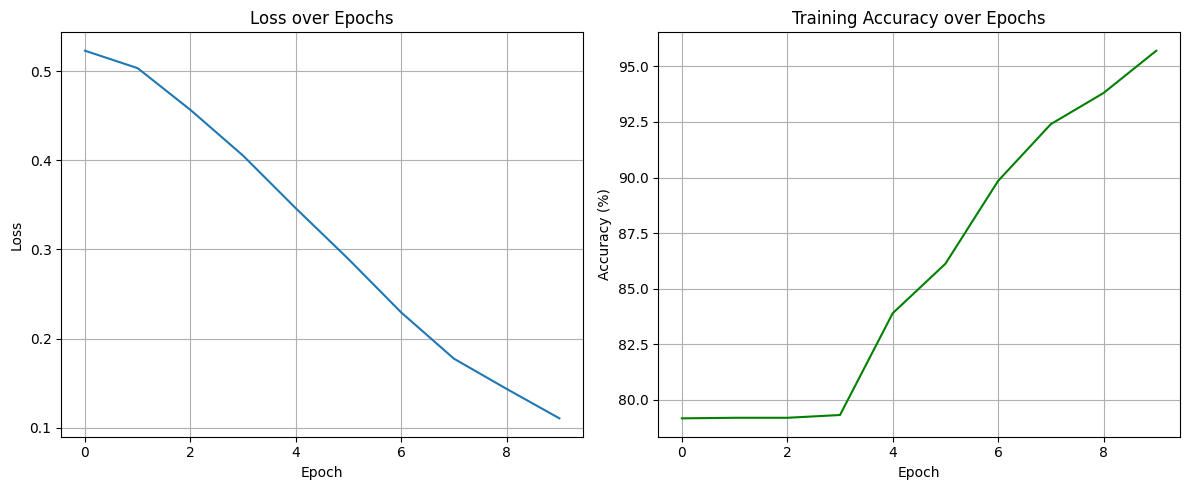

In [ ]:
if __name__ == "__main__":
    main()

Make predictions

In [ ]:
import random

def generate_random_dna(length=101):
    return ''.join(random.choices(['A', 'C', 'G', 'T'], k=length))

random_sequence = generate_random_dna()
print("Random DNA Sequence:\n", random_sequence)



Random DNA Sequence:
 ACAGCAAAGTACTGGTAGGCATAGTAGACGGTCCGAACTTGAATACGCGGGGCACTGGTAGGGCTAGTTATATCGTCCCGGGGCGGTACACCCACGGCCCG


In [ ]:
import torch
import numpy as np

# Reuse model and encoder
def one_hot_encode(seq):
    mapping = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    one_hot = np.zeros((4, len(seq)), dtype=np.float32)
    for i, base in enumerate(seq.upper()):
        if base in mapping:
            one_hot[mapping[base], i] = 1.0
    return one_hot

# Reuse your model definition
class DnaCNN(nn.Module):
    def __init__(self, input_len):
        super(DnaCNN, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=4, out_channels=64, kernel_size=5)
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3)
        self.pool2 = nn.MaxPool1d(2)
        conv_output_size = ((input_len - 4) // 2 - 2) // 2
        self.fc1 = nn.Linear(128 * conv_output_size, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.fc2(x))
        return x.squeeze()

# Run prediction
def predict_single_sequence(seq, model_path="model.pth"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    input_len = len(seq)

    model = DnaCNN(input_len=input_len).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    encoded = one_hot_encode(seq)
    input_tensor = torch.tensor(encoded).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probability = output.item()
        label = 1 if probability > 0.5 else 0

    return probability, label

# Generate and predict
random_seq = generate_random_dna()
prob, label = predict_single_sequence(random_seq)

print("\nPredicted output:")
print("Sequence:     ", random_seq)
print("Probability:  {:.4f}".format(prob))
print("Label:        {}".format("Pathogenic (1)" if label == 1 else "Benign (0)"))



Predicted output:
Sequence:      CACATCGTGCTTCTGGCGTCGTGAACTTCGCGTGCCTCCGCTCGTTTGCAACACGGTTCATTGTCGTGTCCCAGGCGGGCTCAGGCGGGCATCCCATTTAG
Probability:  0.8031
Label:        Pathogenic (1)
